In [1]:
import json

with open("./datasets/yolo/dataset_v2.json", "r") as file:
    yolo_raw_dataset = json.load(file)

with open("./datasets/yolo/selected_joint_names_v2.json", "r") as file:
    selected_joint_names = json.load(file)

In [2]:
selected_joint_names

{'5': 'lhumerus',
 '6': 'rhumerus',
 '11': 'lfemur',
 '12': 'rfemur',
 '13': 'ltibia',
 '14': 'rtibia',
 '15': 'lfoot',
 '16': 'rfoot',
 '7': 'lradius',
 '8': 'rradius',
 '9': 'lwrist',
 '10': 'rwrist'}

In [3]:
selected_joint_names_reversed = {joint_name: int(idx) for idx, joint_name in selected_joint_names.items()}
selected_joint_names_reversed

{'lhumerus': 5,
 'rhumerus': 6,
 'lfemur': 11,
 'rfemur': 12,
 'ltibia': 13,
 'rtibia': 14,
 'lfoot': 15,
 'rfoot': 16,
 'lradius': 7,
 'rradius': 8,
 'lwrist': 9,
 'rwrist': 10}

In [4]:
missed_items = {seq_key: {joint_name : [] for joint_name in selected_joint_names.values()} for seq_key in yolo_raw_dataset.keys()}

for seq_key, cameras in yolo_raw_dataset.items():
    for camera, frames in cameras.items():
        for frame_idx, frame in frames.items():
            for joint_idx, joint_values in enumerate(frame):
                if joint_values == [0.0, 0.0] and str(joint_idx) in selected_joint_names.keys():
                    missed_items[seq_key][selected_joint_names[str(joint_idx)]].append((camera, frame_idx))


In [5]:
total_frames_count = 0

for seq_key, cameras in yolo_raw_dataset.items():
    total_frames_count += len(cameras['c1'])

total_frames_count

18764

In [6]:
joint_names_missed_count = {joint_name : 0 for joint_name in selected_joint_names.values()} 
multiple_missed_frames = {joint_name : 0 for joint_name in selected_joint_names.values()} 

for seq_key, missed_joints in missed_items.items():
    missed_joints_for_seq = {joint : [0 for _ in range(len(yolo_raw_dataset[seq_key]['c1']))] for joint in selected_joint_names.values()}
    print(f"******** {seq_key} ********")
    for joint, missed_frames in missed_joints.items():
        if missed_frames:
            print(f" SINGLE  {joint} - {len(missed_frames)}")
            joint_names_missed_count[joint] += len(missed_frames)

            for camera, frame in missed_frames:
                missed_joints_for_seq[joint][int(frame)] += 1

    fouble_missed_for_seq_counted =  {joint_name : len([i for i in missed_for_seq if i >= 2]) for joint_name, missed_for_seq in missed_joints_for_seq.items()}

    print("")
    for joint, multi_missed_count in fouble_missed_for_seq_counted.items():
        multiple_missed_frames[joint] += multi_missed_count
        if multi_missed_count:
            print(f" MULTI  {joint} - {multi_missed_count}")
            
    print("")

******** p1s1 ********
 SINGLE  lradius - 91
 SINGLE  rradius - 84
 SINGLE  lwrist - 91
 SINGLE  rwrist - 87


******** p1s2 ********
 SINGLE  lhumerus - 1
 SINGLE  rhumerus - 2
 SINGLE  lradius - 80
 SINGLE  rradius - 69
 SINGLE  lwrist - 84
 SINGLE  rwrist - 86

 MULTI  lradius - 2
 MULTI  lwrist - 3
 MULTI  rwrist - 2

******** p1s3 ********
 SINGLE  lradius - 65
 SINGLE  rradius - 64
 SINGLE  lwrist - 71
 SINGLE  rwrist - 66


******** p1s4 ********
 SINGLE  rhumerus - 12
 SINGLE  rfemur - 11
 SINGLE  lradius - 57
 SINGLE  rradius - 66
 SINGLE  lwrist - 64
 SINGLE  rwrist - 80

 MULTI  lradius - 1
 MULTI  rradius - 3
 MULTI  lwrist - 1
 MULTI  rwrist - 6

******** p2s1 ********
 SINGLE  lradius - 64
 SINGLE  rradius - 64
 SINGLE  lwrist - 77
 SINGLE  rwrist - 65


******** p2s2 ********
 SINGLE  lhumerus - 4
 SINGLE  lradius - 62
 SINGLE  rradius - 44
 SINGLE  lwrist - 74
 SINGLE  rwrist - 59

 MULTI  lwrist - 1

******** p2s3 ********
 SINGLE  lradius - 66
 SINGLE  rradius - 45
 S

In [7]:
joint_names_missed_count

{'lhumerus': 225,
 'rhumerus': 280,
 'lfemur': 151,
 'rfemur': 194,
 'ltibia': 89,
 'rtibia': 129,
 'lfoot': 95,
 'rfoot': 146,
 'lradius': 10362,
 'rradius': 9711,
 'lwrist': 11280,
 'rwrist': 10676}

In [8]:
for joint_name, missed_count in joint_names_missed_count.items():
    print(f"{joint_name} : {(100 * missed_count/total_frames_count):.2f}% missed")

lhumerus : 1.20% missed
rhumerus : 1.49% missed
lfemur : 0.80% missed
rfemur : 1.03% missed
ltibia : 0.47% missed
rtibia : 0.69% missed
lfoot : 0.51% missed
rfoot : 0.78% missed
lradius : 55.22% missed
rradius : 51.75% missed
lwrist : 60.12% missed
rwrist : 56.90% missed


In [9]:
multiple_missed_frames

{'lhumerus': 0,
 'rhumerus': 0,
 'lfemur': 0,
 'rfemur': 0,
 'ltibia': 0,
 'rtibia': 0,
 'lfoot': 0,
 'rfoot': 0,
 'lradius': 84,
 'rradius': 65,
 'lwrist': 146,
 'rwrist': 75}

In [10]:
for joint_name, missed_count in multiple_missed_frames.items():
    print(f"{joint_name} : {(100 * missed_count/total_frames_count):.2f}% missed")

lhumerus : 0.00% missed
rhumerus : 0.00% missed
lfemur : 0.00% missed
rfemur : 0.00% missed
ltibia : 0.00% missed
rtibia : 0.00% missed
lfoot : 0.00% missed
rfoot : 0.00% missed
lradius : 0.45% missed
rradius : 0.35% missed
lwrist : 0.78% missed
rwrist : 0.40% missed


In [11]:
cameras = [f'c{i}' for i in range(1,5)]
print(cameras)

print(list(yolo_raw_dataset['p1s1']['c1'].values())[0][selected_joint_names_reversed['lfoot']])
print(list(yolo_raw_dataset['p1s1']['c1'].values())[0][selected_joint_names_reversed['rfoot']])

['c1', 'c2', 'c3', 'c4']
[0.9233218431472778, 0.6504033803939819]
[0.8983641266822815, 0.6370553374290466]


In [12]:
import math
from typing import Sequence

def distance(p1: Sequence[float], p2: Sequence[float]) -> float:
    """
    Calculate Euclidean distance between two points p1 and p2.
    Points are given as [x, y].
    """
    return math.hypot(p2[0] - p1[0], p2[1] - p1[1])


def angle_between_lines(A: Sequence[float], B: Sequence[float], C: Sequence[float], degrees=True) -> float:
    """
    Calculate angle between lines AB and BC.
    Points A, B, C are given as [x, y].

    If degrees=True, returns angle in degrees.
    Otherwise, returns angle in radians.
    """
    BA = (A[0] - B[0], A[1] - B[1])
    BC = (C[0] - B[0], C[1] - B[1])

    dot = BA[0] * BC[0] + BA[1] * BC[1]
    mag_ba = math.hypot(BA[0], BA[1])
    mag_bc = math.hypot(BC[0], BC[1])

    if mag_ba == 0 or mag_bc == 0:
        raise ValueError("Angle is undefined for zero-length line.")

    cos_theta = max(-1.0, min(1.0, dot / (mag_ba * mag_bc)))
    angle = math.acos(cos_theta)

    return math.degrees(angle) if degrees else angle



In [13]:
A = [0, 0]
B = [3, 0]
C = [3, 3]

print("Distance A–B:", distance(A, B))
print("Angle at B:", angle_between_lines(A, B, C), "degrees")

Distance A–B: 3.0
Angle at B: 90.0 degrees


In [14]:
sequence = 'p1s1'

feet_distances = {}

for camera in cameras:
    frames = list(yolo_raw_dataset[sequence][camera].values())
    feet_distance = [distance(frame[selected_joint_names_reversed['lfoot']], frame[selected_joint_names_reversed['rfoot']]) for frame in frames]
    feet_distances[camera] = feet_distance

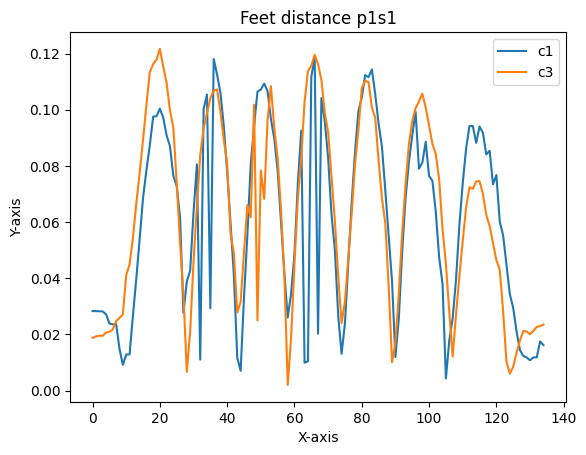

In [15]:
import matplotlib.pyplot as plt
import numpy as np

for camera, distances in feet_distances.items(): 
    if camera in ['c1', 'c3']:
        plt.plot(range(len(distances)), distances, label=camera)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'Feet distance {sequence}')
plt.legend()
plt.show()

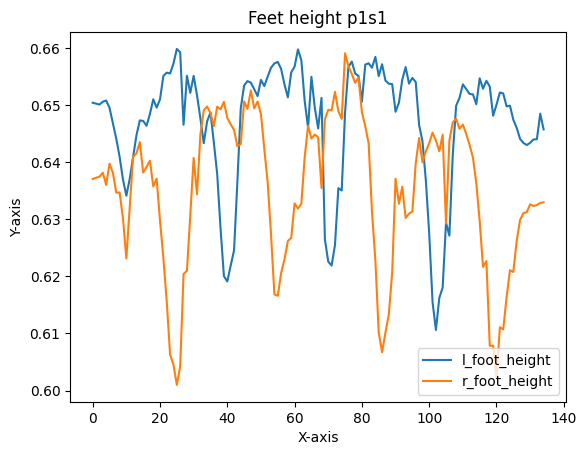

In [16]:
camera = 'c1'
sequence = 'p1s1'

frames = list(yolo_raw_dataset[sequence][camera].values())
l_foot_height = [frame[selected_joint_names_reversed['lfoot']][1] for frame in frames]
r_foot_height = [frame[selected_joint_names_reversed['rfoot']][1] for frame in frames]


plt.plot(range(len(l_foot_height)), l_foot_height, label='l_foot_height')
plt.plot(range(len(r_foot_height)), r_foot_height, label='r_foot_height')

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'Feet height {sequence}')
plt.legend()
plt.show()

In [17]:
from utils.gait_parameters_extractor_raw_2d import CoordinatesIdx2D, GaitParametersExtractorRaw2D

sequence = 'p1s1'
# camera = 'c1'
camera = 'c3'

gpe = GaitParametersExtractorRaw2D(
    sequence_parameters = yolo_raw_dataset[sequence][camera],
    selected_joints = selected_joint_names)


gait_params = gpe.get_gait_parameters()
gait_params.shape

(14, 135)

In [18]:
gait_params_names = gpe.get_gait_parameters_names()
gait_params_names

['legs_angles',
 'left_knee_angles',
 'right_knee_angles',
 'left_hip_angles',
 'right_hip_angles',
 'left_humerus_angles',
 'right_humerus_angles',
 'left_elbow_angles',
 'right_elbow_angles',
 'ankle_distances',
 'knee_distances',
 'elbow_distances',
 'hand_distances',
 'center_of_gravity_height_change']

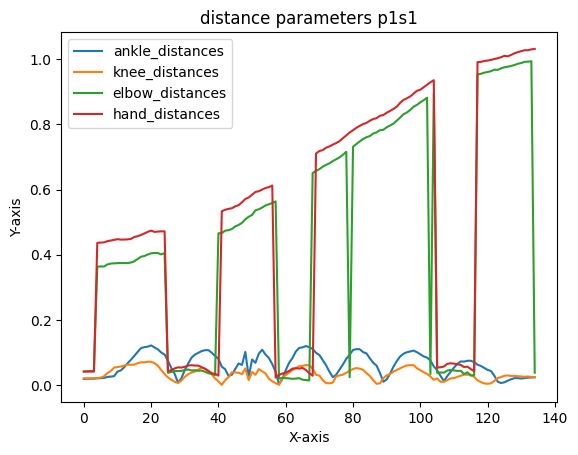

In [19]:
for name, params_value in zip(gait_params_names, gait_params): 
    if 'distance' in name:
        plt.plot(range(len(params_value)), params_value, label=name)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'distance parameters {sequence}')
plt.legend()
plt.show()

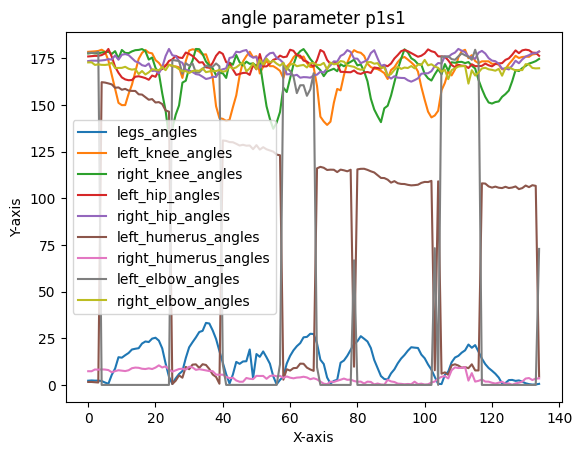

In [20]:
for name, params_value in zip(gait_params_names, gait_params): 
    if 'angle' in name:
        plt.plot(range(len(params_value)), params_value, label=name)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'angle parameter {sequence}')
plt.legend()
plt.show()

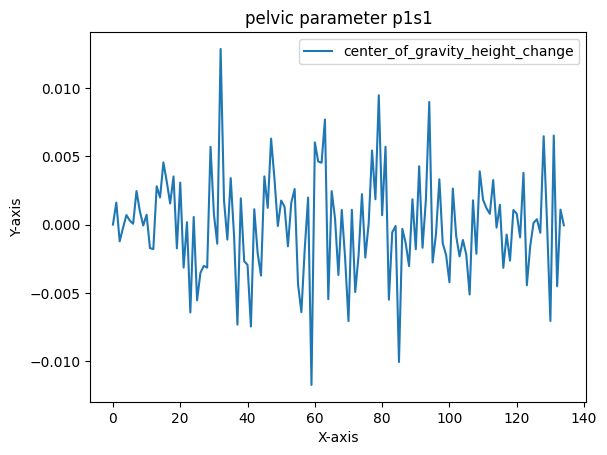

In [21]:
for name, params_value in zip(gait_params_names, gait_params): 
    if 'center' in name:
        plt.plot(range(len(params_value)), params_value, label=name)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'pelvic parameter {sequence}')
plt.legend()
plt.show()

In [22]:
np.array(gpe.get_gait_angles()).shape

(9, 135)

In [23]:
np.array(gpe.get_joint_distances()).shape

(4, 135)

In [24]:
np.array(gpe.get_pelvic_parameters()).shape

(135,)

In [25]:
gpe.get_step_frames()

First right step recognized as probably marked incorrectly and removed


([10, 40, 70, 103, 123], [24, 55, 87, 120])

In [26]:
def _calc_step_frames(steps: list) -> list[int]:
    step_frames = []
    for i in range(len(steps)-1):
        step_frames.append(steps[i+1] - steps[i])
    return step_frames

def _fragment_step_frames(steps: list, window_size: int = 32) -> list[tuple[int, int]]:
    step_frames = []
    for i in range(len(steps)-1):
        center = steps[i] + (steps[i+1] - steps[i])//2
        start_frame = center - window_size//2
        end_frame = center + window_size//2
        step_frames.append((start_frame, end_frame))
    return step_frames

In [27]:
def separate_gait_sequences_to_cycles(data_2d, 
                                      selected_joint_names,
                                      camera: str = 'c1',
                                      window_size: int = 32,
                                      minima_window_size: int = 10,
                                      running_average_window_size: int = 1,
                                      coordinates_index: CoordinatesIdx2D = CoordinatesIdx2D(),
                                      print_stats: bool = True,
                                     ):
    results = {}
    cum_step_frames = []
    side = ''
    fail_counter = 0
    
    for seq_key in list(data_2d.keys()):
        gpe = GaitParametersExtractorRaw2D(
            sequence_parameters = data_2d[seq_key][camera],
            selected_joints = selected_joint_names,
            window_size = running_average_window_size,
        )

        l_steps, r_steps = gpe.get_step_frames(window_size = minima_window_size)
        
        if len(l_steps)>1 and len(r_steps)>1:
            steps_sequence = []
            if l_steps[0] < r_steps[0]:
                cum_step_frames += _calc_step_frames(l_steps)
                steps_sequence = _fragment_step_frames(l_steps, window_size)
                side = 'L'
            else:
                cum_step_frames += _calc_step_frames(r_steps)
                steps_sequence = _fragment_step_frames(r_steps, window_size)
                side = 'R'

            if print_stats:
                print(f"{seq_key} [{side}] - {steps_sequence}")
            for i, (start_frame, end_frame) in enumerate(steps_sequence):
                results[f"{seq_key}c{i}"] = {str(idx) : joints for idx, joints in enumerate(list(data_2d[seq_key][camera].values())[start_frame:end_frame])}
        else:
            fail_counter += 1

    if print_stats:
        print("   Steps: ", len(cum_step_frames))
        print("    Mean: ", sum(cum_step_frames)/len(cum_step_frames))
        print("     Max: ", max(cum_step_frames))
        print("     Min: ", min(cum_step_frames))
        print("  Median: ", sorted(cum_step_frames)[len(cum_step_frames)//2])
        print(" Over 32: ", sum(1 for step in cum_step_frames if step>32))
        print("  Failed: ", fail_counter)

    return results

In [28]:
results = separate_gait_sequences_to_cycles(
    data_2d = yolo_raw_dataset,
    selected_joint_names = selected_joint_names,
    minima_window_size = 14,
    camera = 'c1'
)

with open("./datasets/yolo/sequences_2d/steps_camera_1.json", "w") as f:
    json.dump(results, f, indent=4)

p1s1 [R] - [(24, 56), (54, 86), (87, 119)]
p1s2 [R] - [(25, 57), (56, 88)]
p1s3 [R] - [(20, 52), (50, 82), (81, 113)]
Failed to find proper step frame keys
p2s1 [L] - [(24, 56), (53, 85), (85, 117)]
p2s2 [L] - [(16, 48), (44, 76), (72, 104)]
p2s3 [R] - [(21, 53), (49, 81), (79, 111)]
Failed to find proper step frame keys
p3s1 [R] - [(23, 55), (52, 84), (82, 114)]
p3s2 [L] - [(13, 45), (39, 71), (68, 100)]
p3s3 [R] - [(23, 55), (53, 85), (84, 116)]
Failed to find proper step frame keys
p4s1 [R] - [(26, 58), (57, 89)]
p4s2 [R] - [(24, 56), (55, 87)]
p4s3 [L] - [(24, 56), (56, 88)]
Failed to find proper step frame keys
p5s1 [L] - [(25, 57), (56, 88), (89, 121)]
p5s2 [L] - [(28, 60), (61, 93), (93, 125)]
p5s3 [L] - [(27, 59), (59, 91), (92, 124)]
Failed to find proper step frame keys
p6s1 [R] - [(18, 50), (44, 76)]
p6s2 [R] - [(22, 54), (48, 80)]
p6s3 [L] - [(19, 51), (46, 78), (74, 106)]
Failed to find proper step frame keys
p7s1 [L] - [(22, 54), (49, 81), (76, 108)]
p7s2 [L] - [(15, 47),

In [29]:
results = separate_gait_sequences_to_cycles(
    data_2d = yolo_raw_dataset,
    selected_joint_names = selected_joint_names,
    minima_window_size = 14,
    camera = 'c3'
)

with open("./datasets/yolo/sequences_2d/steps_camera_3.json", "w") as f:
    json.dump(results, f, indent=4)

p1s1 [R] - [(23, 55), (55, 87), (87, 119)]
Failed to find proper step frame keys
p1s3 [R] - [(20, 52), (49, 81), (81, 113)]
p1s4 [R] - [(21, 53), (51, 83)]
p2s1 [L] - [(25, 57), (55, 87), (85, 117)]
Failed to find proper step frame keys
p2s3 [R] - [(21, 53), (49, 81), (79, 111)]
p2s4 [L] - [(21, 53), (47, 79)]
p3s1 [R] - [(23, 55), (52, 84), (81, 113)]
Failed to find proper step frame keys
p3s3 [R] - [(22, 54), (52, 84), (83, 115)]
p3s4 [L] - [(22, 54), (47, 79)]
p4s1 [R] - [(26, 58), (58, 90)]
Failed to find proper step frame keys
p4s3 [L] - [(24, 56), (55, 87)]
p4s4 [L] - [(22, 54), (52, 84)]
p5s1 [L] - [(25, 57), (57, 89), (90, 122)]
p5s2 [R] - [(54, 86), (112, 144)]
p5s3 [L] - [(27, 59), (59, 91), (91, 123)]
p5s4 [L] - [(28, 60), (59, 91), (91, 123)]
p6s1 [R] - [(18, 50), (43, 75)]
Failed to find proper step frame keys
p6s3 [L] - [(19, 51), (45, 77), (74, 106)]
p6s4 [R] - [(20, 52), (46, 78)]
p7s1 [L] - [(21, 53), (49, 81), (76, 108)]
Last right step recognized as probably marked i

In [30]:
results = separate_gait_sequences_to_cycles(
    data_2d = yolo_raw_dataset,
    selected_joint_names = selected_joint_names,
    minima_window_size = 14,
    camera = 'c1',
    running_average_window_size = 3,
)

with open("./datasets/yolo/sequences_2d/steps_camera_1_smoothed.json", "w") as f:
    json.dump(results, f, indent=4)

p1s1 [R] - [(24, 56), (54, 86), (86, 118)]
p1s2 [R] - [(25, 57), (55, 87)]
p1s3 [R] - [(20, 52), (50, 82), (81, 113)]
Failed to find proper step frame keys
p2s1 [L] - [(23, 55), (53, 85), (85, 117)]
p2s2 [L] - [(16, 48), (43, 75), (72, 104)]
p2s3 [R] - [(21, 53), (49, 81), (79, 111)]
Failed to find proper step frame keys
p3s1 [R] - [(23, 55), (52, 84), (81, 113)]
p3s2 [L] - [(13, 45), (39, 71), (68, 100)]
p3s3 [R] - [(23, 55), (53, 85), (84, 116)]
Failed to find proper step frame keys
p4s1 [R] - [(26, 58), (58, 90)]
p4s2 [R] - [(23, 55), (54, 86)]
p4s3 [L] - [(24, 56), (56, 88)]
Failed to find proper step frame keys
p5s1 [L] - [(25, 57), (56, 88), (89, 121)]
p5s2 [L] - [(29, 61), (61, 93), (93, 125)]
p5s3 [L] - [(28, 60), (60, 92), (92, 124)]
Failed to find proper step frame keys
p6s1 [R] - [(17, 49), (44, 76)]
p6s2 [R] - [(23, 55), (49, 81)]
p6s3 [L] - [(19, 51), (46, 78), (74, 106)]
Failed to find proper step frame keys
p7s1 [R] - [(10, 42), (36, 68), (63, 95)]
p7s2 [L] - [(15, 47), 

In [31]:
results = separate_gait_sequences_to_cycles(
    data_2d = yolo_raw_dataset,
    selected_joint_names = selected_joint_names,
    minima_window_size = 14,
    camera = 'c3',
    running_average_window_size = 3,
)

with open("./datasets/yolo/sequences_2d/steps_camera_3_smoothed.json", "w") as f:
    json.dump(results, f, indent=4)

p1s1 [R] - [(24, 56), (54, 86), (87, 119)]
Failed to find proper step frame keys
p1s3 [R] - [(20, 52), (50, 82), (81, 113)]
p1s4 [R] - [(22, 54), (51, 83)]
p2s1 [L] - [(25, 57), (54, 86), (84, 116)]
Failed to find proper step frame keys
p2s3 [R] - [(22, 54), (49, 81), (79, 111)]
p2s4 [L] - [(21, 53), (47, 79)]
p3s1 [R] - [(22, 54), (51, 83), (81, 113)]
Failed to find proper step frame keys
p3s3 [R] - [(22, 54), (53, 85), (84, 116)]
p3s4 [L] - [(22, 54), (47, 79)]
p4s1 [R] - [(26, 58), (58, 90)]
Failed to find proper step frame keys
p4s3 [L] - [(24, 56), (55, 87)]
p4s4 [L] - [(22, 54), (52, 84)]
p5s1 [L] - [(25, 57), (57, 89), (90, 122)]
p5s2 [R] - [(112, 144)]
p5s3 [L] - [(27, 59), (59, 91), (91, 123)]
p5s4 [L] - [(29, 61), (60, 92), (91, 123)]
p6s1 [R] - [(17, 49), (44, 76)]
Failed to find proper step frame keys
p6s3 [L] - [(18, 50), (45, 77), (74, 106)]
p6s4 [R] - [(20, 52), (46, 78)]
p7s1 [L] - [(21, 53), (49, 81), (76, 108)]
Failed to find proper step frame keys
p7s3 [R] - [(22, 54

In [32]:
results['p1s1c0']

{'0': [[0.20612064003944397, 0.2375676929950714],
  [0.0, 0.0],
  [0.20120634138584137, 0.22721542418003082],
  [0.0, 0.0],
  [0.18325433135032654, 0.2289140820503235],
  [0.19810229539871216, 0.28482118248939514],
  [0.1696101278066635, 0.2916385531425476],
  [0.0, 0.0],
  [0.16262364387512207, 0.3713882863521576],
  [0.0, 0.0],
  [0.16694863140583038, 0.4412990212440491],
  [0.20106272399425507, 0.4251367449760437],
  [0.17741107940673828, 0.4295651316642761],
  [0.2145819514989853, 0.5254748463630676],
  [0.1835421919822693, 0.5372933745384216],
  [0.213137686252594, 0.6355812549591064],
  [0.12956154346466064, 0.5933098793029785]],
 '1': [[0.212191641330719, 0.23502540588378906],
  [0.21386896073818207, 0.22511833906173706],
  [0.20687082409858704, 0.22476933896541595],
  [0.0, 0.0],
  [0.18907548487186432, 0.2254897505044937],
  [0.2059556096792221, 0.2857006788253784],
  [0.17558616399765015, 0.28625720739364624],
  [0.20736578106880188, 0.36226698756217957],
  [0.170283019542694

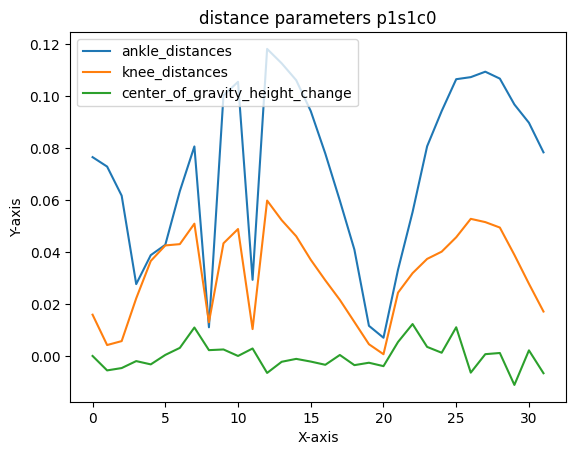

In [33]:
import json
import matplotlib.pyplot as plt
from utils.gait_parameters_extractor_raw_2d import CoordinatesIdx2D, GaitParametersExtractorRaw2D


with open("./datasets/yolo/sequences_2d/steps_camera_1.json", "r") as file:
    yolo_2d_dataset = json.load(file)

with open("./datasets/yolo/selected_joint_names_v2.json", "r") as file:
    selected_joint_names = json.load(file)

gait_cycle = 'p1s1c0'

gpe = GaitParametersExtractorRaw2D(
    sequence_parameters = yolo_2d_dataset[gait_cycle],
    selected_joints = selected_joint_names
)

gait_params = gpe.get_gait_parameters()
gait_params_names = gpe.get_gait_parameters_names()

for name, params_value in zip(gait_params_names, gait_params): 
    if name in ['ankle_distances', 'knee_distances', 'center_of_gravity_height_change']:
        plt.plot(range(len(params_value)), params_value, label=name)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title(f'distance parameters {gait_cycle}')
plt.legend()
plt.show()